# **Titanic Tutorial for Beginner**

<h4>Thank you for visiting my notebook :)</h4>
<h4>This notebook explains easily how to start a competition for beginner!!</h4>

<div class="list-group" id="list-tab" role="tablist">
<h2 style='color:white; background:#707C4F; border:0' role="tab" aria-controls="home"><center>Contents</center></h2>
    
* **Import Library**
    
* **Load Data**
    
* **EDA & Preprocessing**
    
* **Modeling**
    
* **Evaluation**
    
* **Submission**

# **Import Library**


<h4>In the kaggle notebook environment, you can import most of the libraries you want to use</h4>

* pandas → Python Data Analysis Library

* numpy → Linear algebra library that performs numerical operations such as vectors and matrices in Python

* matplotlib & seaborn → Visualization Library

In [173]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, RobustScaler, MinMaxScaler, LabelEncoder
from sklearn.impute import KNNImputer
from sklearn.model_selection import train_test_split, StratifiedKFold
from catboost import CatBoostClassifier
from xgboost import XGBClassifier

In [174]:
# You don't have to run this code!
# It's just for clean visualization :)

import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

palette = sns.color_palette("bright")
sns.set_palette("Paired")

# **Load Data**

<h4>Using 'read_csv()' function in Pandas, you can read .csv file easily</h4>

In [175]:
train = pd.read_csv('../input/titanic/train.csv')
test = pd.read_csv('../input/titanic/test.csv')
sub = pd.read_csv('../input/titanic/gender_submission.csv')

all_data = pd.concat([train, test]).reset_index(drop = True)
all_data

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0.0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1.0,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1.0,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1.0,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0.0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
1304,1305,NaN,3,"Spector, Mr. Woolf",male,NaN,0,0,A.5. 3236,8.0500,NaN,S
1305,1306,NaN,1,"Oliva y Ocana, Dona. Fermina",female,39.0,0,0,PC 17758,108.9000,C105,C
1306,1307,NaN,3,"Saether, Mr. Simon Sivertsen",male,38.5,0,0,SOTON/O.Q. 3101262,7.2500,NaN,S
1307,1308,NaN,3,"Ware, Mr. Frederick",male,NaN,0,0,359309,8.0500,NaN,S


*****

# **EDA & Preprocessing**

<h4>EDA is an abbreviation of Exploratory Data Analysis !</h4>

<h4>You can use 'Matplotlib & Seaborn' for Basic EDA :)</h4>

<h4>With visualization, we can see the distribution of train, test data's features</h4>

#### **Based on the information obtained through the above work, we can preprocess the data**

* ### **Countplot**

#### Since this competition is a binary classification competition, you can check the balance of the target column using **countplot.**

<h4>With below graph, we can see that Target(Survived) column is unbalanced.</h4>

<h4>It's too bad that there are more people who haven't survived.</h4>

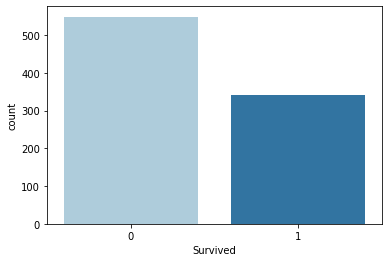

In [176]:
sns.countplot(train['Survived']);

#### **We can also check the distribution of categorical columns!**

#### **You can use 'nunique()' function to check which column is categorical**

In [177]:
all_data.nunique().sort_values()

Survived          2
Sex               2
Pclass            3
Embarked          3
SibSp             7
Parch             8
Age              98
Cabin           186
Fare            281
Ticket          929
Name           1307
PassengerId    1309
dtype: int64

<h4>With above output, we can check top 4 columns are categorical.</h4>

#### SibSp & Parch are not categorical columns!! You can visit [here](https://www.kaggle.com/c/titanic/data) and see the detail explanations about columns

#### So! Let's check about the distribution of those 4 columns using **Countplot**

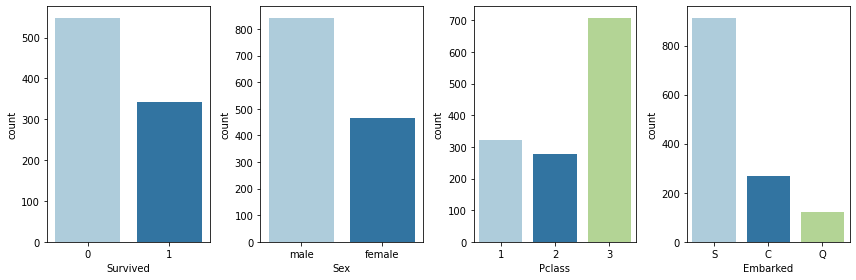

In [178]:
fig, ax = plt.subplots(1, 4, figsize = (12, 4)) # Making Subplots

sns.countplot(train['Survived'], ax=ax[0]);
sns.countplot(all_data['Sex'], ax=ax[1]);
sns.countplot(all_data['Pclass'], ax=ax[2]);
sns.countplot(all_data['Embarked'], ax=ax[3]);

plt.tight_layout() # you can use this function for clear visualization
plt.show()

#### **We checked the distribution of categorical columns!**

#### **Now, aren't you curious about gender and survival rate?**

#### Using **groupby()** function, the relationship between columns can be grasped!

In [179]:
sex_survived_rate = all_data.groupby('Sex')['Survived'].mean()
sex_survived_rate

Sex
female    0.742038
male      0.188908
Name: Survived, dtype: float64

#### From the graph below, we can see that despite the large number of male passengers,
#### the survival rate of male passengers is significantly lower than that of female passengers.

#### Maybe thanks to captain's leadership

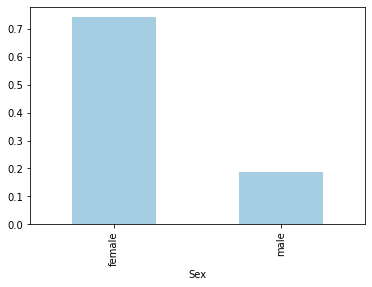

In [180]:
sex_survived_rate.plot(kind = 'bar');

#### You can practice with Pclass, Embarked columns!!
#### Do it youself :)

*****

* ### **distplot**

#### With distplot, you can check the distribution of numeric columns!

#### Below graphs : distribution of Age, Fare

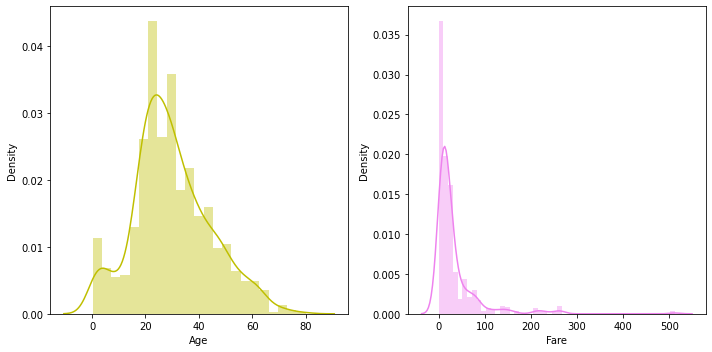

In [181]:
fig, ax = plt.subplots(1, 2, figsize = (10, 5))

sns.distplot(all_data['Age'], ax=ax[0], color='y');
sns.distplot(all_data['Fare'], ax=ax[1], color='violet');

plt.tight_layout()
plt.show()

#### Fare column looks like be skewed!!

#### Maybe need to use scaler! (ex. StandardScaler, RobustScaler, LogScaling)

#### If we use scaler, our model will be less affected by outliers. Check an image below :)

#### You can use scalers using function 'fit_transform()'

#### **!! Need to transform your target value using reshape(-1, 1) !!**

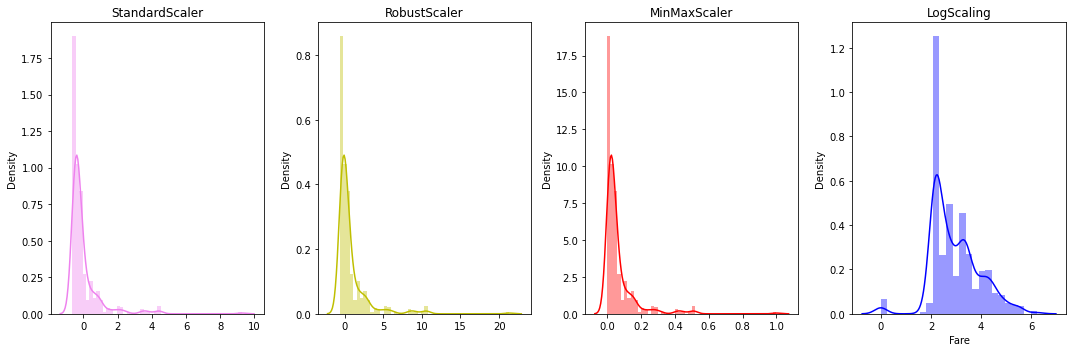

In [182]:
ss = StandardScaler()
rb = RobustScaler()
mm = MinMaxScaler()

fare_standard = ss.fit_transform(all_data['Fare'].values.reshape(-1, 1))
fare_robust = rb.fit_transform(all_data['Fare'].values.reshape(-1, 1))
fare_minmax = mm.fit_transform(all_data['Fare'].values.reshape(-1, 1))

fig, ax = plt.subplots(1, 4, figsize=(15, 5))

sns.distplot(fare_standard, color='violet', ax = ax[0]).set_title('StandardScaler');
sns.distplot(fare_robust, color='y', ax = ax[1]).set_title('RobustScaler');
sns.distplot(fare_minmax, color='r', ax = ax[2]).set_title('MinMaxScaler');
sns.distplot(np.log1p(train['Fare']), color='b', ax = ax[3]).set_title('LogScaling');

plt.tight_layout()
plt.show()

#### You can choose the scaler that has the highest performance of the model while using all four scalers above

#### **Log Scaling** seems to be attractive → Because of **skewness**

#### In this notebook, we will use **Log Scaling** :)

*****

*  ## **Now, we need to check Missing Values**

### You can use 'isna().sum()' function to see how many missing values are there

In [183]:
all_data.isna().sum()

PassengerId       0
Survived        418
Pclass            0
Name              0
Sex               0
Age             263
SibSp             0
Parch             0
Ticket            0
Fare              1
Cabin          1014
Embarked          2
dtype: int64

#### We can make good features using missing values!

* **The number of missing values**
* **One-Hot-Encoding - Missing values Y/N**

#### Let's make a feature of **the number of missing values**

* **Excepting PassengerId, Survived columns**

In [184]:
all_data['missing_counts'] = all_data[all_data.columns[2:]].isna().sum(axis = 1)
all_data

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,missing_counts
0,1,0.0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S,1
1,2,1.0,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,0
2,3,1.0,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,1
3,4,1.0,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,0
4,5,0.0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1304,1305,NaN,3,"Spector, Mr. Woolf",male,NaN,0,0,A.5. 3236,8.0500,NaN,S,2
1305,1306,NaN,1,"Oliva y Ocana, Dona. Fermina",female,39.0,0,0,PC 17758,108.9000,C105,C,0
1306,1307,NaN,3,"Saether, Mr. Simon Sivertsen",male,38.5,0,0,SOTON/O.Q. 3101262,7.2500,NaN,S,1
1307,1308,NaN,3,"Ware, Mr. Frederick",male,NaN,0,0,359309,8.0500,NaN,S,2


#### Next, making a feature about the presence or absence of missing values

In [185]:
miss_one_hot = all_data[['Age', 'Cabin', 'Fare', 'Embarked']].isna()
miss_one_hot.columns = ['Age_miss', 'Cabin_miss', 'Fare_miss', 'Embarked_miss']
miss_one_hot

,Age_miss,Cabin_miss,Fare_miss,Embarked_miss
0,False,True,False,False
1,False,False,False,False
2,False,True,False,False
3,False,False,False,False
4,False,True,False,False
...,...,...,...,...
1304,True,True,False,False
1305,False,False,False,False
1306,False,True,False,False
1307,True,True,False,False


#### You must concat those dataframe using axis = 1 !!

In [186]:
all_data = pd.concat([all_data, miss_one_hot], axis = 1)
all_data

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,missing_counts,Age_miss,Cabin_miss,Fare_miss,Embarked_miss
0,1,0.0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S,1,False,True,False,False
1,2,1.0,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,0,False,False,False,False
2,3,1.0,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,1,False,True,False,False
3,4,1.0,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,0,False,False,False,False
4,5,0.0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S,1,False,True,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1304,1305,NaN,3,"Spector, Mr. Woolf",male,NaN,0,0,A.5. 3236,8.0500,NaN,S,2,True,True,False,False
1305,1306,NaN,1,"Oliva y Ocana, Dona. Fermina",female,39.0,0,0,PC 17758,108.9000,C105,C,0,False,False,False,False
1306,1307,NaN,3,"Saether, Mr. Simon Sivertsen",male,38.5,0,0,SOTON/O.Q. 3101262,7.2500,NaN,S,1,False,True,False,False
1307,1308,NaN,3,"Ware, Mr. Frederick",male,NaN,0,0,359309,8.0500,NaN,S,2,True,True,False,False


#### **EDA is a really important technique in data science**

#### **Many features can be extracted, which plays an important role in improving model performance**

#### **Then, how can we handle those missing values?**

#### Answer is..

* **Fill in the numeric column with -1 and the categorical column with just 'nan'**

* **Fill in the numeric column with each column's mean value**

* **Predict the missing values using ML models** → **KNN Imputer**

#### In this notebook, I'll use knn imputer for numeric columns and fill 'nan' for categorical column

#### For KnnImputer, I think it would be helpful to use the LableEncoder

In [187]:
all_data['Cabin'] = all_data['Cabin'].fillna('nan')
all_data['Embarked'] = all_data['Embarked'].fillna('nan')

le = LabelEncoder()

all_data['Cabin'] = le.fit_transform(all_data['Cabin'])
all_data['Sex'] = le.fit_transform(all_data['Sex'])
all_data['Embarked'] = le.fit_transform(all_data['Embarked'])
all_data

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,missing_counts,Age_miss,Cabin_miss,Fare_miss,Embarked_miss
0,1,0.0,3,"Braund, Mr. Owen Harris",1,22.0,1,0,A/5 21171,7.2500,186,2,1,False,True,False,False
1,2,1.0,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",0,38.0,1,0,PC 17599,71.2833,106,0,0,False,False,False,False
2,3,1.0,3,"Heikkinen, Miss. Laina",0,26.0,0,0,STON/O2. 3101282,7.9250,186,2,1,False,True,False,False
3,4,1.0,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",0,35.0,1,0,113803,53.1000,70,2,0,False,False,False,False
4,5,0.0,3,"Allen, Mr. William Henry",1,35.0,0,0,373450,8.0500,186,2,1,False,True,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1304,1305,NaN,3,"Spector, Mr. Woolf",1,NaN,0,0,A.5. 3236,8.0500,186,2,2,True,True,False,False
1305,1306,NaN,1,"Oliva y Ocana, Dona. Fermina",0,39.0,0,0,PC 17758,108.9000,64,0,0,False,False,False,False
1306,1307,NaN,3,"Saether, Mr. Simon Sivertsen",1,38.5,0,0,SOTON/O.Q. 3101262,7.2500,186,2,1,False,True,False,False
1307,1308,NaN,3,"Ware, Mr. Frederick",1,NaN,0,0,359309,8.0500,186,2,2,True,True,False,False


#### Need to except Name, PassengerId, Survived, Ticket columns for Imputing

In [188]:
columns = list(all_data.columns)
columns.remove('PassengerId')
columns.remove('Survived')
columns.remove('Ticket')
columns.remove('Name')
columns

['Pclass',
 'Sex',
 'Age',
 'SibSp',
 'Parch',
 'Fare',
 'Cabin',
 'Embarked',
 'missing_counts',
 'Age_miss',
 'Cabin_miss',
 'Fare_miss',
 'Embarked_miss']

#### **Knn Imputer**

In [189]:
knn = KNNImputer()

imputed_data = all_data[columns]
imputed_data = knn.fit_transform(imputed_data)
imputed_data

array([[ 3. ,  1. , 22. , ...,  1. ,  0. ,  0. ],
       [ 1. ,  0. , 38. , ...,  0. ,  0. ,  0. ],
       [ 3. ,  0. , 26. , ...,  1. ,  0. ,  0. ],
       ...,
       [ 3. ,  1. , 38.5, ...,  1. ,  0. ,  0. ],
       [ 3. ,  1. , 24.5, ...,  1. ,  0. ,  0. ],
       [ 3. ,  1. , 22.8, ...,  1. ,  0. ,  0. ]])

#### You must use iloc or loc for edit dataframe!

In [190]:
all_data.iloc[:, 5] = imputed_data[:, 2]
all_data.iloc[:, 9] = imputed_data[:, 5]
all_data

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,missing_counts,Age_miss,Cabin_miss,Fare_miss,Embarked_miss
0,1,0.0,3,"Braund, Mr. Owen Harris",1,22.0,1,0,A/5 21171,7.2500,186,2,1,False,True,False,False
1,2,1.0,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",0,38.0,1,0,PC 17599,71.2833,106,0,0,False,False,False,False
2,3,1.0,3,"Heikkinen, Miss. Laina",0,26.0,0,0,STON/O2. 3101282,7.9250,186,2,1,False,True,False,False
3,4,1.0,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",0,35.0,1,0,113803,53.1000,70,2,0,False,False,False,False
4,5,0.0,3,"Allen, Mr. William Henry",1,35.0,0,0,373450,8.0500,186,2,1,False,True,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1304,1305,NaN,3,"Spector, Mr. Woolf",1,24.5,0,0,A.5. 3236,8.0500,186,2,2,True,True,False,False
1305,1306,NaN,1,"Oliva y Ocana, Dona. Fermina",0,39.0,0,0,PC 17758,108.9000,64,0,0,False,False,False,False
1306,1307,NaN,3,"Saether, Mr. Simon Sivertsen",1,38.5,0,0,SOTON/O.Q. 3101262,7.2500,186,2,1,False,True,False,False
1307,1308,NaN,3,"Ware, Mr. Frederick",1,24.5,0,0,359309,8.0500,186,2,2,True,True,False,False


### **Clear!**

In [191]:
all_data.isna().sum()

PassengerId         0
Survived          418
Pclass              0
Name                0
Sex                 0
Age                 0
SibSp               0
Parch               0
Ticket              0
Fare                0
Cabin               0
Embarked            0
missing_counts      0
Age_miss            0
Cabin_miss          0
Fare_miss           0
Embarked_miss       0
dtype: int64

*****

* ### **Preprocessing Name, Ticket columns**

#### Thank you for following me all the way here. Please cheer up a little bit more. We're almost there :)

#### **I think that name column is very important**

#### **If the family in the train data survived, other family members in the test data are more likely to survive.**

In [193]:
name=[]
for i in range(len(all_data['Name'])):
    name.append(all_data['Name'].iloc[i].split(',')[1].split('.')[0])
all_data['Name']=name
all_data['Name']=all_data['Name'].replace([' Dr',' Mlle',' Rev',' Major',' Col',' Don',' the Countess',' Lady',' Jonkheer',' Sir',' Mme',' Ms',' Capt',' Dona'],'Rare')
all_data['Name']=all_data['Name'].replace({' Mr':1,' Miss':2,' Mrs':2,' Master':3,'Rare':4})

name=[]
for i in range(len(test['Name'])):
    name.append(test['Name'].iloc[i].split(',')[1].split('.')[0])
test['Name']=name
test['Name']=test['Name'].replace([' Dr',' Mlle',' Rev',' Major',' Col',' Don',' the Countess',' Lady',' Jonkheer',' Sir',' Mme',' Ms',' Capt',' Dona'],'Rare')
test['Name']=test['Name'].replace({' Mr':1,' Miss':2,' Mrs':2,' Master':3,'Rare':4})

## **Ticket?**

#### **At first, we need to split by space**

In [194]:
ticket_split = all_data['Ticket'].apply(lambda x : x.split(' '))
ticket_split

0                [A/5, 21171]
1                 [PC, 17599]
2         [STON/O2., 3101282]
3                    [113803]
4                    [373450]
                ...          
1304             [A.5., 3236]
1305              [PC, 17758]
1306    [SOTON/O.Q., 3101262]
1307                 [359309]
1308                   [2668]
Name: Ticket, Length: 1309, dtype: object

#### **How about binning those group??**

#### Using agg(len), we can group those ticket data

#### Code presumed to be the type of ticket is included at the beginning of the list (A/5, STON/, etc..)

In [195]:
ticket_2 = ticket_split[ticket_split.agg(len) == 2]
ticket_2

0                [A/5, 21171]
1                 [PC, 17599]
2         [STON/O2., 3101282]
10                 [PP, 9549]
12               [A/5., 2151]
                ...          
1296         [SC/PARIS, 2166]
1300    [SOTON/O.Q., 3101315]
1304             [A.5., 3236]
1305              [PC, 17758]
1306    [SOTON/O.Q., 3101262]
Name: Ticket, Length: 332, dtype: object

In [196]:
ticket_2_index = ticket_split[ticket_split.agg(len) == 2].index
ticket_2_index

Int64Index([   0,    1,    2,   10,   12,   30,   31,   33,   34,   37,
            ...
            1266, 1275, 1282, 1283, 1284, 1296, 1300, 1304, 1305, 1306],
           dtype='int64', length=332)

In [197]:
ticket_code_2 = []

for i in ticket_2.index:
    ticket_code_2.append(ticket_2[i][0])
    
ticket_code_2

['A/5',
 'PC',
 'STON/O2.',
 'PP',
 'A/5.',
 'PC',
 'PC',
 'C.A.',
 'PC',
 'A./5.',
 'SC/Paris',
 'S.C./A.4.',
 'A/4.',
 'PC',
 'C.A.',
 'C.A.',
 'CA',
 'PC',
 'C.A.',
 'S.P.',
 'C.A.',
 'CA',
 'S.O.C.',
 'SO/C',
 'W./C.',
 'SOTON/OQ',
 'W.E.P.',
 'C.A.',
 'PC',
 'PC',
 'PC',
 'S.O.C.',
 'A4.',
 'C',
 'SOTON/O.Q.',
 'A/5.',
 'C.A.',
 'SC/PARIS',
 'PC',
 'STON/O2.',
 'C.A.',
 'W./C.',
 'S.O.P.',
 'A.5.',
 'A/5.',
 'Fa',
 'PC',
 'SOTON/OQ',
 'CA.',
 'C.A.',
 'PC',
 'PC',
 'CA.',
 'SC/PARIS',
 'PC',
 'PC',
 'CA.',
 'A/5',
 'SOTON/O.Q.',
 'F.C.C.',
 'A/5',
 'STON/O2.',
 'W/C',
 'SOTON/OQ',
 'PP',
 'SW/PP',
 'A/5',
 'C.A.',
 'W./C.',
 'C.A.',
 'SCO/W',
 'W./C.',
 'A/5.',
 'PC',
 'PC',
 'C.A.',
 'PC',
 'PC',
 'PC',
 'C.A.',
 'A/5.',
 'SC/Paris',
 'PC',
 'PC',
 'A/5',
 'PC',
 'P/PP',
 'PC',
 'PC',
 'F.C.C.',
 'A/5',
 'CA.',
 'PC',
 'PC',
 'PC',
 'C.A.',
 'SC/PARIS',
 'SOTON/O.Q.',
 'C',
 'PC',
 'PC',
 'PC',
 'C',
 'PC',
 'S.O.C.',
 'CA',
 'SC',
 'PP',
 'STON/O2.',
 'A/5.',
 'A/4.',
 'SOTON/O.

In [198]:
ticket_code_2_labeled = le.fit_transform(ticket_code_2)
ticket_code_2_labeled += 1
ticket_code_2_labeled

array([ 5, 21, 41, 22,  6, 21, 21, 12, 21,  1, 35, 23,  4, 21, 12, 12, 14,
       21, 12, 28, 12, 14, 26, 37, 44, 40, 45, 12, 21, 21, 21, 26,  8, 11,
       38,  6, 12, 34, 21, 41, 12, 44, 27,  2,  6, 18, 21, 40, 15, 12, 21,
       21, 15, 34, 21, 21, 15,  5, 38, 17,  5, 41, 46, 40, 22, 43,  5, 12,
       44, 12, 36, 44,  6, 21, 21, 12, 21, 21, 21, 12,  6, 35, 21, 21,  5,
       21, 20, 21, 21, 17,  5, 15, 21, 21, 21, 12, 34, 38, 11, 21, 21, 21,
       11, 21, 26, 14, 30, 22, 41,  6,  4, 38, 33, 44, 12, 17, 12,  5, 17,
        7, 38, 12, 14,  5,  2, 12, 40, 21,  3, 12, 21, 11, 40, 21, 21, 12,
       44, 21, 17, 21, 47, 21, 34, 12, 21, 40, 38,  3, 29, 21,  4,  1,  5,
       33, 21, 35, 21, 38,  6, 12, 21, 21, 25, 15, 26, 21, 26,  5, 16, 12,
       14, 21, 21, 14, 35, 21, 21, 21, 21, 21, 41, 44, 21, 21, 47, 12, 39,
       25, 44, 38, 12, 21, 15, 21, 12,  3, 41, 24, 11, 24, 21, 39, 25, 12,
       15, 21, 15, 34, 21, 20, 13, 40, 44,  3, 45, 34, 41, 21, 11, 21, 21,
       21,  6, 33, 12, 12

In [199]:
ticket_3 = ticket_split[ticket_split.agg(len) == 3]
ticket_3

115     [STON/O, 2., 3101294]
173     [STON/O, 2., 3101280]
243     [STON/O, 2., 3101275]
382     [STON/O, 2., 3101293]
400     [STON/O, 2., 3101289]
414     [STON/O, 2., 3101269]
433     [STON/O, 2., 3101274]
473       [SC/AH, Basle, 541]
579     [STON/O, 2., 3101286]
590     [STON/O, 2., 3101273]
636     [STON/O, 2., 3101292]
664     [STON/O, 2., 3101285]
744     [STON/O, 2., 3101288]
936     [STON/O, 2., 3101291]
988     [STON/O, 2., 3101268]
1159          [A., 2., 39186]
Name: Ticket, dtype: object

In [200]:
ticket_3_index = ticket_split[ticket_split.agg(len) == 3].index

ticket_code_3 = []

for i in ticket_3.index:
    ticket_code_3.append(ticket_3[i][0])
    
ticket_code_3

['STON/O',
 'STON/O',
 'STON/O',
 'STON/O',
 'STON/O',
 'STON/O',
 'STON/O',
 'SC/AH',
 'STON/O',
 'STON/O',
 'STON/O',
 'STON/O',
 'STON/O',
 'STON/O',
 'STON/O',
 'A.']

In [201]:
ticket_code_3_labeled = le.fit_transform(ticket_code_3)
ticket_code_3_labeled += ticket_code_2_labeled.max()
ticket_code_3_labeled

array([49, 49, 49, 49, 49, 49, 49, 48, 49, 49, 49, 49, 49, 49, 49, 47])

#### Making new columns !

In [202]:
all_data['ticket_code'] = 0
all_data

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,missing_counts,Age_miss,Cabin_miss,Fare_miss,Embarked_miss,ticket_code
0,1,0.0,3,1,1,22.0,1,0,A/5 21171,7.2500,186,2,1,False,True,False,False,0
1,2,1.0,1,2,0,38.0,1,0,PC 17599,71.2833,106,0,0,False,False,False,False,0
2,3,1.0,3,2,0,26.0,0,0,STON/O2. 3101282,7.9250,186,2,1,False,True,False,False,0
3,4,1.0,1,2,0,35.0,1,0,113803,53.1000,70,2,0,False,False,False,False,0
4,5,0.0,3,1,1,35.0,0,0,373450,8.0500,186,2,1,False,True,False,False,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1304,1305,NaN,3,1,1,24.5,0,0,A.5. 3236,8.0500,186,2,2,True,True,False,False,0
1305,1306,NaN,1,4,0,39.0,0,0,PC 17758,108.9000,64,0,0,False,False,False,False,0
1306,1307,NaN,3,1,1,38.5,0,0,SOTON/O.Q. 3101262,7.2500,186,2,1,False,True,False,False,0
1307,1308,NaN,3,1,1,24.5,0,0,359309,8.0500,186,2,2,True,True,False,False,0


In [203]:
all_data.loc[ticket_2_index, 'ticket_code'] = list(ticket_code_2_labeled)
all_data.loc[ticket_3_index, 'ticket_code'] = list(ticket_code_3_labeled)
all_data

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,missing_counts,Age_miss,Cabin_miss,Fare_miss,Embarked_miss,ticket_code
0,1,0.0,3,1,1,22.0,1,0,A/5 21171,7.2500,186,2,1,False,True,False,False,5
1,2,1.0,1,2,0,38.0,1,0,PC 17599,71.2833,106,0,0,False,False,False,False,21
2,3,1.0,3,2,0,26.0,0,0,STON/O2. 3101282,7.9250,186,2,1,False,True,False,False,41
3,4,1.0,1,2,0,35.0,1,0,113803,53.1000,70,2,0,False,False,False,False,0
4,5,0.0,3,1,1,35.0,0,0,373450,8.0500,186,2,1,False,True,False,False,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1304,1305,NaN,3,1,1,24.5,0,0,A.5. 3236,8.0500,186,2,2,True,True,False,False,2
1305,1306,NaN,1,4,0,39.0,0,0,PC 17758,108.9000,64,0,0,False,False,False,False,21
1306,1307,NaN,3,1,1,38.5,0,0,SOTON/O.Q. 3101262,7.2500,186,2,1,False,True,False,False,38
1307,1308,NaN,3,1,1,24.5,0,0,359309,8.0500,186,2,2,True,True,False,False,0


#### **Done!!!**

In [204]:
all_data2 = all_data.drop(columns = ['Ticket', 'Survived', 'PassengerId'])
all_data2

,Pclass,Name,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked,missing_counts,Age_miss,Cabin_miss,Fare_miss,Embarked_miss,ticket_code
0,3,1,1,22.0,1,0,7.2500,186,2,1,False,True,False,False,5
1,1,2,0,38.0,1,0,71.2833,106,0,0,False,False,False,False,21
2,3,2,0,26.0,0,0,7.9250,186,2,1,False,True,False,False,41
3,1,2,0,35.0,1,0,53.1000,70,2,0,False,False,False,False,0
4,3,1,1,35.0,0,0,8.0500,186,2,1,False,True,False,False,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1304,3,1,1,24.5,0,0,8.0500,186,2,2,True,True,False,False,2
1305,1,4,0,39.0,0,0,108.9000,64,0,0,False,False,False,False,21
1306,3,1,1,38.5,0,0,7.2500,186,2,1,False,True,False,False,38
1307,3,1,1,24.5,0,0,8.0500,186,2,2,True,True,False,False,0


## Scaling

In [205]:
all_data2['Fare'] = np.log1p(all_data2['Fare'])

# **Modeling**

## There are many **categorical columns!**

### How about using **CatBoost**?

* ### **Train_Test_Split**

#### **Using validation data for evaluation**

#### **In case of classification competition, you can use option 'stratify' for seperation balance**

In [206]:
train2 = all_data2[:len(train)]
test2 = all_data2[len(train):].reset_index(drop = True)

In [207]:
x_train, x_valid, y_train, y_valid = train_test_split(train2, train['Survived'], test_size = 0.2, random_state = 42, stratify = train['Survived'])

In [214]:
cat = CatBoostClassifier(verbose = 1000,
                         eval_metric='Accuracy',
                         early_stopping_rounds=1000,
                         n_estimators=10000,
                         learning_rate = 0.025,
                         max_depth=7)

cat.fit(x_train, y_train, eval_set=[(x_valid, y_valid)])

result = cat.predict(test2)

sub['Survived'] = result

sub.to_csv('sub_catboost.csv', index = 0)

0:	learn: 0.8384831	test: 0.7709497	best: 0.7709497 (0)	total: 3.07ms	remaining: 30.7s
1000:	learn: 0.9789326	test: 0.7932961	best: 0.8324022 (78)	total: 1.64s	remaining: 14.7s
Stopped by overfitting detector  (1000 iterations wait)

bestTest = 0.8324022346
bestIteration = 78

Shrink model to first 79 iterations.


* ### **Stratified Kfold**

#### You can use the code below for your stratifiedKfold Baseline

In [271]:
stk = StratifiedKFold(n_splits=5, random_state = 42, shuffle = True)

result_cat = 0

for fold, (train_index, valid_index) in enumerate(stk.split(train2, train['Survived'])):
    x_train, y_train = train2.iloc[train_index], train['Survived'][train_index]
    x_valid, y_valid = train2.iloc[valid_index], train['Survived'][valid_index]
    
    cat = CatBoostClassifier(verbose = 1000,
                         eval_metric='Accuracy',
                         early_stopping_rounds=1000,
                         n_estimators=10000,
                         learning_rate = 0.02,
                         max_depth=8)
    print('----------Fold', fold+1, 'Start!--------')
    cat.fit(x_train, y_train, eval_set=[(x_valid, y_valid)])
    print('----------Fold', fold+1, 'Done!--------')
    result_cat += cat.predict_proba(test2)[:, 1] / 5

print('All Done!')

----------Fold 1 Start!--------
0:	learn: 0.8216292	test: 0.8268156	best: 0.8268156 (0)	total: 4.45ms	remaining: 44.5s
1000:	learn: 0.9775281	test: 0.8603352	best: 0.8715084 (507)	total: 2.18s	remaining: 19.6s
Stopped by overfitting detector  (1000 iterations wait)

bestTest = 0.8715083799
bestIteration = 507

Shrink model to first 508 iterations.
----------Fold 1 Done!--------
----------Fold 2 Start!--------
0:	learn: 0.8330996	test: 0.8089888	best: 0.8089888 (0)	total: 9.2ms	remaining: 1m 31s
1000:	learn: 0.9845722	test: 0.8314607	best: 0.8539326 (556)	total: 2.17s	remaining: 19.6s
Stopped by overfitting detector  (1000 iterations wait)

bestTest = 0.8539325843
bestIteration = 556

Shrink model to first 557 iterations.
----------Fold 2 Done!--------
----------Fold 3 Start!--------
0:	learn: 0.8288920	test: 0.7696629	best: 0.7696629 (0)	total: 2.57ms	remaining: 25.7s
1000:	learn: 0.9803647	test: 0.7921348	best: 0.8314607 (25)	total: 2.2s	remaining: 19.8s
Stopped by overfitting detecto

In [274]:
sub['Survived'] = result_cat
sub['Survived'] = sub['Survived'].astype(np.int64)
sub.to_csv('sub_cat_stratifiedkfold.csv', index = 0)

## **Thank you so much for reading it until the end**
## **I'm glad if it helped you!**
## **If this notebook helped you to learn, please do not forget the Upvote!!**